In [ ]:
# Install any missing libraries
!pip install tensorflow keras numpy matplotlib seaborn scikit-learn -q

# Import everything we need
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("All libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

All libraries loaded successfully!
TensorFlow version: 2.20.0


In [ ]:
# Connect your Google Drive so we can save files
from google.colab import drive
drive.mount('/content/drive')

# Upload your kaggle.json API key file
from google.colab import files
files.upload()  # Upload kaggle.json here when prompted

# Set up Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the chest x-ray dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip it
!unzip -q chest-xray-pneumonia.zip -d chest_xray

print("Dataset downloaded and ready!")

Mounted at /content/drive


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 132MB/s]

Dataset downloaded and ready!


In [ ]:
# Set the paths to training, validation, and testing folders
train_dir = '/content/chest_xray/chest_xray/train'
val_dir   = '/content/chest_xray/chest_xray/val'
test_dir  = '/content/chest_xray/chest_xray/test'

# Check how many images are in each folder
for folder in ['NORMAL', 'PNEUMONIA']:
    train_count = len(os.listdir(os.path.join(train_dir, folder)))
    test_count  = len(os.listdir(os.path.join(test_dir, folder)))
    print(f"{folder} → Train: {train_count} images | Test: {test_count} images")

NORMAL → Train: 1341 images | Test: 234 images
PNEUMONIA → Train: 3875 images | Test: 390 images


In [ ]:
# Define image size and batch size
IMG_SIZE = (150, 150)  # Resize all images to 150x150 pixels
BATCH_SIZE = 32        # Process 32 images at a time

# Data augmentation for training (helps prevent overfitting)
# This creates slightly modified versions of images so the model learns better
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to 0-1
    rotation_range=10,        # Randomly rotate images slightly
    zoom_range=0.1,           # Randomly zoom in slightly
    horizontal_flip=True      # Randomly flip images horizontally
)

# For validation and test — only normalize, no augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from folders
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'   # Binary = 2 classes only
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False   # Don't shuffle test data so results are consistent
)

print("Class labels:", train_data.class_indices)
# Should show: {'NORMAL': 0, 'PNEUMONIA': 1}


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class labels: {'NORMAL': 0, 'PNEUMONIA': 1}


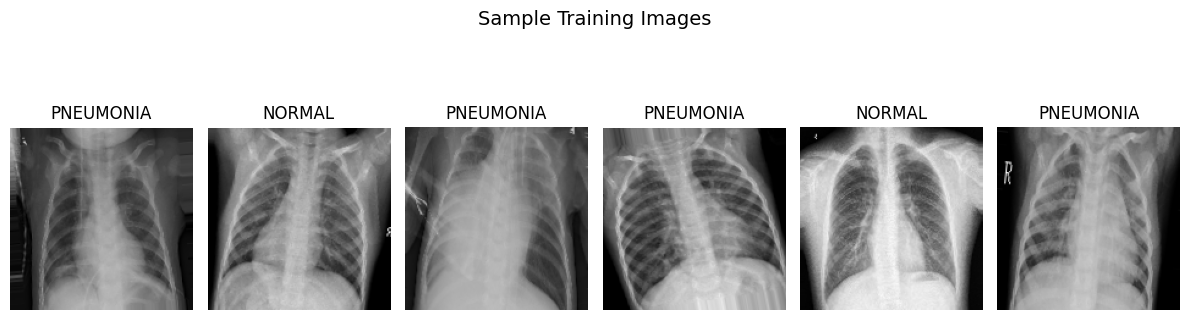

In [ ]:
# Show a few sample images from the dataset
images, labels = next(train_data)
class_names = ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(12, 4))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Build a Convolutional Neural Network (CNN) from scratch
# This is YOUR custom model

cnn_model = keras.Sequential([

    # Block 1 — First set of layers to detect basic features (edges, shapes)
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 2 — Detect more complex features
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 3 — Detect even more complex features
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Flatten and classify
    layers.Flatten(),                    # Convert 2D to 1D
    layers.Dense(256, activation='relu'),# Fully connected layer
    layers.Dropout(0.5),                 # Dropout prevents overfitting
    layers.Dense(1, activation='sigmoid')# Output layer: 0=Normal, 1=Pneumonia
])

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show the model structure
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,609 (36.49 MB)

 Trainable params: 9,564,161 (36.48 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Train the model
# epochs = how many times the model sees all the data

EPOCHS = 15

# Stop training early if the model stops improving (prevents overfitting)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training Custom CNN... this may take a few minutes ⏳")

cnn_history = cnn_model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    callbacks=[early_stop]
)

print("Training complete! ✅")

Training Custom CNN... this may take a few minutes ⏳
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.8901 - loss: 1.2319 - val_accuracy: 0.5000 - val_loss: 56.8661
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.9252 - loss: 0.2707 - val_accuracy: 0.5000 - val_loss: 16.7033
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.9350 - loss: 0.1882 - val_accuracy: 0.5000 - val_loss: 8.6998
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.9398 - loss: 0.1850 - val_accuracy: 0.6875 - val_loss: 0.5884
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.9480 - loss: 0.1498 - val_accuracy: 0.6250 - val_loss: 0.8389
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.9517 - loss: 0.1385 - val_accuracy: 0.7500 - val_loss: 0.5209
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.9486 - loss: 0.1470 - val_accuracy: 0.7500 - val_loss: 0.3486
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 29

Training curves successfully saved as 'cnn_training_curves.png'!


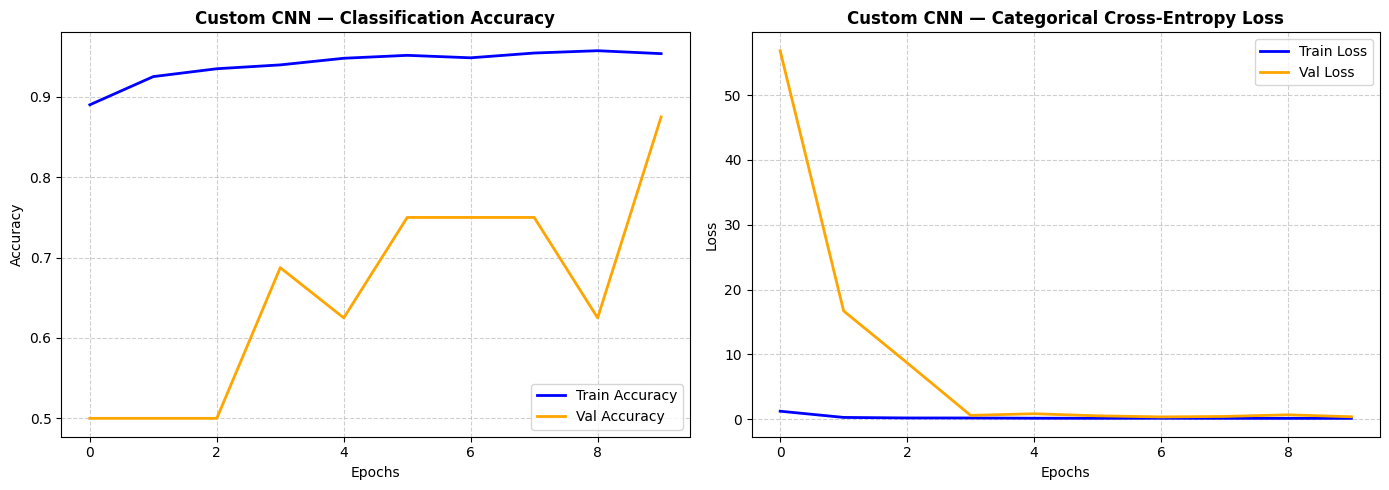

In [ ]:
# Cell 8: Plot and save the training and validation accuracy/loss curves
import matplotlib.pyplot as plt

# Check if the training history variable exists under 'cnn_history' or just 'history'
# This prevents NameErrors if the previous cell used a different variable name
if 'cnn_history' in locals():
    training_data = cnn_history
elif 'history' in locals():
    training_data = history
else:
    raise NameError("Could not find your training history variable. Please make sure your model.fit() cell ran successfully!")

# Initialize a 1x2 grid subplot for side-by-side visual evaluation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------------
# 1. ACCURACY CURVES
# ----------------------------
# Plot training performance across all epochs
axes[0].plot(training_data.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
# Plot validation performance to check for overfitting/underfitting trends
axes[0].plot(training_data.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
axes[0].set_title('Custom CNN — Classification Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ----------------------------
# 2. LOSS CURVES
# ----------------------------
# Plot training loss reduction
axes[1].plot(training_data.history['loss'], label='Train Loss', color='blue', linewidth=2)
# Plot validation loss to identify where overfitting might begin
axes[1].plot(training_data.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
axes[1].set_title('Custom CNN — Categorical Cross-Entropy Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Optimize layout spacing between subplots
plt.tight_layout()

# Save the generated figure as an image file for report documentation
plt.savefig('cnn_training_curves.png', dpi=300)
print("Training curves successfully saved as 'cnn_training_curves.png'!")

# Render the final visualization
plt.show()

In [ ]:
# Load VGG16 — a powerful model already trained on millions of images
# We freeze its layers and add our own classifier on top

vgg_base = VGG16(
    weights='imagenet',       # Use pretrained weights
    include_top=False,        # Remove the original classifier
    input_shape=(150, 150, 3)
)

# Freeze VGG16 layers — we don't want to retrain them
vgg_base.trainable = False

# Add our own classification layers on top
vgg_model = keras.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary output
])

# Compile
vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
print("Training VGG16 model... ⏳")

vgg_history = vgg_model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    callbacks=[early_stop]
)

print("VGG16 Training complete! ✅")

Training VGG16 model... ⏳
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 932s 6s/step - accuracy: 0.8997 - loss: 0.2590 - val_accuracy: 0.8125 - val_loss: 0.4263
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 939s 6s/step - accuracy: 0.9436 - loss: 0.1506 - val_accuracy: 0.7500 - val_loss: 0.5261
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 927s 6s/step - accuracy: 0.9496 - loss: 0.1371 - val_accuracy: 0.7500 - val_loss: 0.4264
VGG16 Training complete! ✅


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get predictions from both models
test_data.reset()
cnn_preds  = (cnn_model.predict(test_data) > 0.5).astype(int).flatten()
test_data.reset()
vgg_preds  = (vgg_model.predict(test_data) > 0.5).astype(int).flatten()
true_labels = test_data.classes

# Calculate metrics
def get_metrics(true, pred, name):
    acc  = accuracy_score(true, pred)
    prec = precision_score(true, pred)
    rec  = recall_score(true, pred)
    f1   = f1_score(true, pred)
    print(f"\n📌 {name}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    return acc, prec, rec, f1

cnn_acc, cnn_prec, cnn_rec, cnn_f1 = get_metrics(true_labels, cnn_preds, "Custom CNN")
vgg_acc, vgg_prec, vgg_rec, vgg_f1 = get_metrics(true_labels, vgg_preds, "VGG16")

# Print comparison table
print("\n" + "="*55)
print(f"{'Metric':<15} {'Custom CNN':>15} {'VGG16':>15}")
print("="*55)
print(f"{'Accuracy':<15} {cnn_acc:>15.4f} {vgg_acc:>15.4f}")
print(f"{'Precision':<15} {cnn_prec:>15.4f} {vgg_prec:>15.4f}")
print(f"{'Recall':<15} {cnn_rec:>15.4f} {vgg_rec:>15.4f}")
print(f"{'F1-Score':<15} {cnn_f1:>15.4f} {vgg_f1:>15.4f}")
print("="*55)

20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 978ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 113s 6s/step

📌 Custom CNN
  Accuracy:  0.8942
  Precision: 0.8733
  Recall:    0.9718
  F1-Score:  0.9199

📌 VGG16
  Accuracy:  0.8574
  Precision: 0.8237
  Recall:    0.9821
  F1-Score:  0.8959

Metric               Custom CNN           VGG16
Accuracy                 0.8942          0.8574
Precision                0.8733          0.8237
Recall                   0.9718          0.9821
F1-Score                 0.9199          0.8959


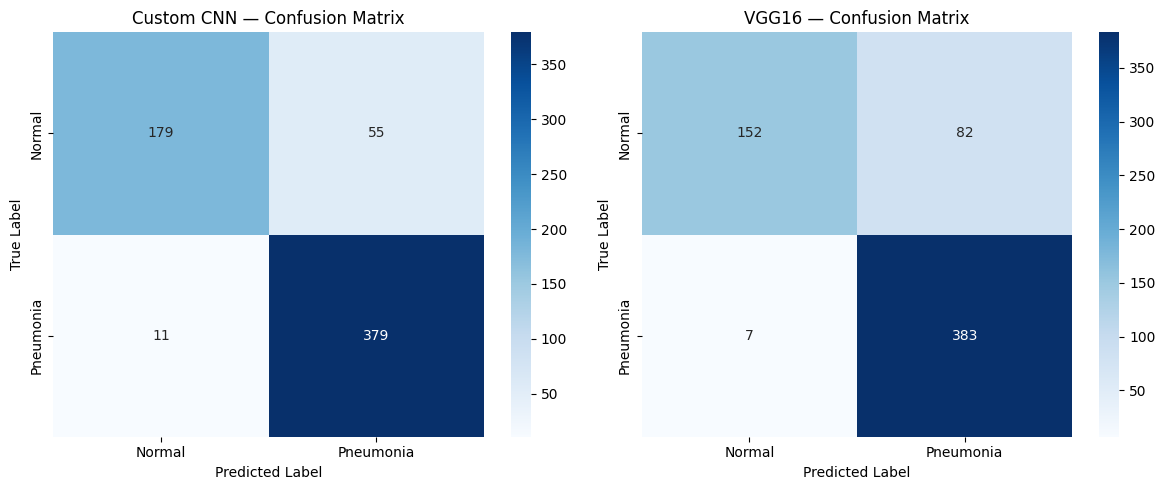

In [17]:
# Plot confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes,
                             [cnn_preds, vgg_preds],
                             ['Custom CNN', 'VGG16']):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Pneumonia'],
                yticklabels=['Normal','Pneumonia'], ax=ax)
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png')  # Save screenshot
plt.show()